In [1]:
# ============================================================
# CELL 1: DATA SETUP — NIFTY 50 OHLCV + INDIA VIX
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# --- Fetch Nifty 50 OHLCV data ---
# Using ^NSEI (NSE index ticker on Yahoo Finance)
# Start from 2009 because India VIX was launched in March 2009
nifty = yf.download('^NSEI', start='2009-01-01', auto_adjust=True)

# --- Fetch India VIX data ---
# ^INDIAVIX is the Yahoo Finance ticker for India VIX
vix = yf.download('^INDIAVIX', start='2009-01-01', auto_adjust=True)

# --- Merge on date ---
# Inner join keeps only dates where BOTH Nifty and VIX traded
# This automatically removes holidays, missing days, mismatches
df = pd.DataFrame()
df['Open'] = nifty['Open']
df['High'] = nifty['High']
df['Low'] = nifty['Low']
df['Close'] = nifty['Close']
df['Volume'] = nifty['Volume']
df['VIX'] = vix['Close']
df.dropna(inplace=True)

# --- Calculate return and range metrics ---

# Daily return: close-to-close percentage change
df['Nifty_Return'] = df['Close'].pct_change() * 100

# Daily range: (High - Low) / Close — measures actual intraday movement as %
# This is realized intraday volatility — we'll compare this against VIX's prediction
df['Daily_Range_Pct'] = ((df['High'] - df['Low']) / df['Close']) * 100

# VIX daily change in absolute points (e.g., 15 to 17 = +2)
df['VIX_Change'] = df['VIX'].diff()

# VIX percentage change — more meaningful than absolute change
# VIX 10→12 is a 20% jump (big), VIX 30→32 is 6.7% (noise)
df['VIX_Pct_Change'] = df['VIX'].pct_change() * 100

# Drop first row (NaN from pct_change/diff)
df.dropna(inplace=True)

# --- Quick data quality check ---
print(f"Date range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Total trading days: {len(df)}")
print(f"\nNifty 50 range: {df['Close'].min():.0f} to {df['Close'].max():.0f}")
print(f"India VIX range: {df['VIX'].min():.1f} to {df['VIX'].max():.1f}")
print(f"\nAvg daily range (High-Low): {df['Daily_Range_Pct'].mean():.2f}%")
print(f"Avg daily return: {df['Nifty_Return'].mean():.4f}%")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date range: 2009-01-05 to 2026-05-29
Total trading days: 4250

Nifty 50 range: 2573 to 26329
India VIX range: 9.1 to 83.6

Avg daily range (High-Low): 1.26%
Avg daily return: 0.0550%

Missing values:
Open               0
High               0
Low                0
Close              0
Volume             0
VIX                0
Nifty_Return       0
Daily_Range_Pct    0
VIX_Change         0
VIX_Pct_Change     0
dtype: int64

First 5 rows:


,Open,High,Low,Close,Volume,VIX,Nifty_Return,Daily_Range_Pct,VIX_Change,VIX_Pct_Change
Date,,,,,,,,,,
2009-01-05,3058.750000,3131.949951,3056.449951,3121.449951,0,38.599998,2.451791,2.418748,-2.070000,-5.089746
2009-01-06,3121.500000,3141.800049,3056.100098,3112.800049,0,38.730000,-0.277112,2.753147,0.130001,0.336790
2009-01-07,3112.800049,3147.199951,2888.199951,2920.399902,0,44.360001,-6.180935,8.868648,5.630001,14.536538
2009-01-09,2919.949951,2929.850098,2810.250000,2873.000000,0,47.820000,-1.623062,4.162899,3.459999,7.799817
2009-01-12,2868.850098,2869.199951,2748.550049,2773.100098,0,47.820000,-3.477198,4.350723,0.000000,0.000000


In [2]:
# ============================================================
# CELL 2: DESCRIPTIVE STATISTICS + STATIONARITY TESTS
# ============================================================

from scipy import stats
from statsmodels.tsa.stattools import adfuller

# --- Summary statistics for key series ---
summary_cols = ['Close', 'VIX', 'Nifty_Return', 'Daily_Range_Pct', 'VIX_Pct_Change']
summary = df[summary_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(4)
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print(summary)

# --- Distribution shape for returns and VIX ---
print("\n" + "=" * 70)
print("DISTRIBUTION SHAPE ANALYSIS")
print("=" * 70)

for col, label in [('Nifty_Return', 'Nifty Daily Returns (%)'),
                    ('VIX', 'India VIX Level'),
                    ('VIX_Pct_Change', 'VIX Daily % Change'),
                    ('Daily_Range_Pct', 'Nifty Daily Range (%)')]:

    series = df[col].dropna()
    skew = series.skew()
    kurt = series.kurtosis()  # Excess kurtosis (0 = normal)

    # Jarque-Bera: tests if data is normally distributed
    # Null hypothesis = data IS normal. Low p-value = NOT normal
    jb_stat, jb_pval = stats.jarque_bera(series)

    print(f"\n{label}:")
    print(f"  Skewness: {skew:.3f}", end="")
    # Negative skew = left tail is fatter (more extreme drops)
    # Positive skew = right tail is fatter (more extreme spikes)
    if skew < -0.5: print("  ← Left-skewed (crash-prone)")
    elif skew > 0.5: print("  ← Right-skewed (spike-prone)")
    else: print("  ← Roughly symmetric")

    print(f"  Kurtosis: {kurt:.3f}", end="")
    # Kurtosis > 0 means fatter tails than normal distribution
    # Financial data almost always has positive excess kurtosis
    if kurt > 3: print("  ← Very fat tails (extreme moves happen more than normal predicts)")
    elif kurt > 0: print("  ← Moderately fat tails")
    else: print("  ← Thin tails")

    print(f"  Jarque-Bera p-value: {jb_pval:.6f}", end="")
    print("  ← NOT normal" if jb_pval < 0.05 else "  ← Consistent with normal")

# --- Stationarity Tests (ADF) ---
print("\n" + "=" * 70)
print("STATIONARITY TESTS (Augmented Dickey-Fuller)")
print("=" * 70)
print("Null hypothesis: series has a unit root (non-stationary)")
print("If p-value < 0.05 → reject null → series IS stationary\n")

for col, label in [('Close', 'Nifty Price Level'),
                    ('Nifty_Return', 'Nifty Daily Returns'),
                    ('VIX', 'India VIX Level'),
                    ('VIX_Pct_Change', 'VIX Daily % Change')]:

    series = df[col].dropna()
    # maxlag=20 limits lag selection to avoid overfitting on long series
    result = adfuller(series, maxlag=20, autolag='AIC')
    adf_stat, pval = result[0], result[1]

    status = "✅ STATIONARY" if pval < 0.05 else "❌ NON-STATIONARY"
    print(f"{label:.<35} ADF stat: {adf_stat:>8.3f} | p-value: {pval:.6f} | {status}")

DESCRIPTIVE STATISTICS
            Close        VIX  Nifty_Return  Daily_Range_Pct  VIX_Pct_Change
count   4250.0000  4250.0000     4250.0000        4250.0000       4250.0000
mean   11672.7283    18.9089        0.0550           1.2631          0.1305
std     6543.6577     7.7906        1.1411           0.9101          5.6608
min     2573.1499     9.1500      -12.9805           0.2461        -33.9407
5%      4831.6099    11.3745       -1.6543           0.4820         -7.5463
25%     5983.7623    14.0200       -0.4940           0.7369         -2.7796
50%     9674.8247    16.8200        0.0644           1.0382         -0.2662
75%    17051.2871    21.0875        0.6280           1.4951          2.5541
95%    24787.7823    34.2505        1.7175           2.7791          8.9354
max    26328.5508    83.6100       17.7441          16.4498         65.6250

DISTRIBUTION SHAPE ANALYSIS

Nifty Daily Returns (%):
  Skewness: 0.368  ← Roughly symmetric
  Kurtosis: 21.557  ← Very fat tails (extreme m

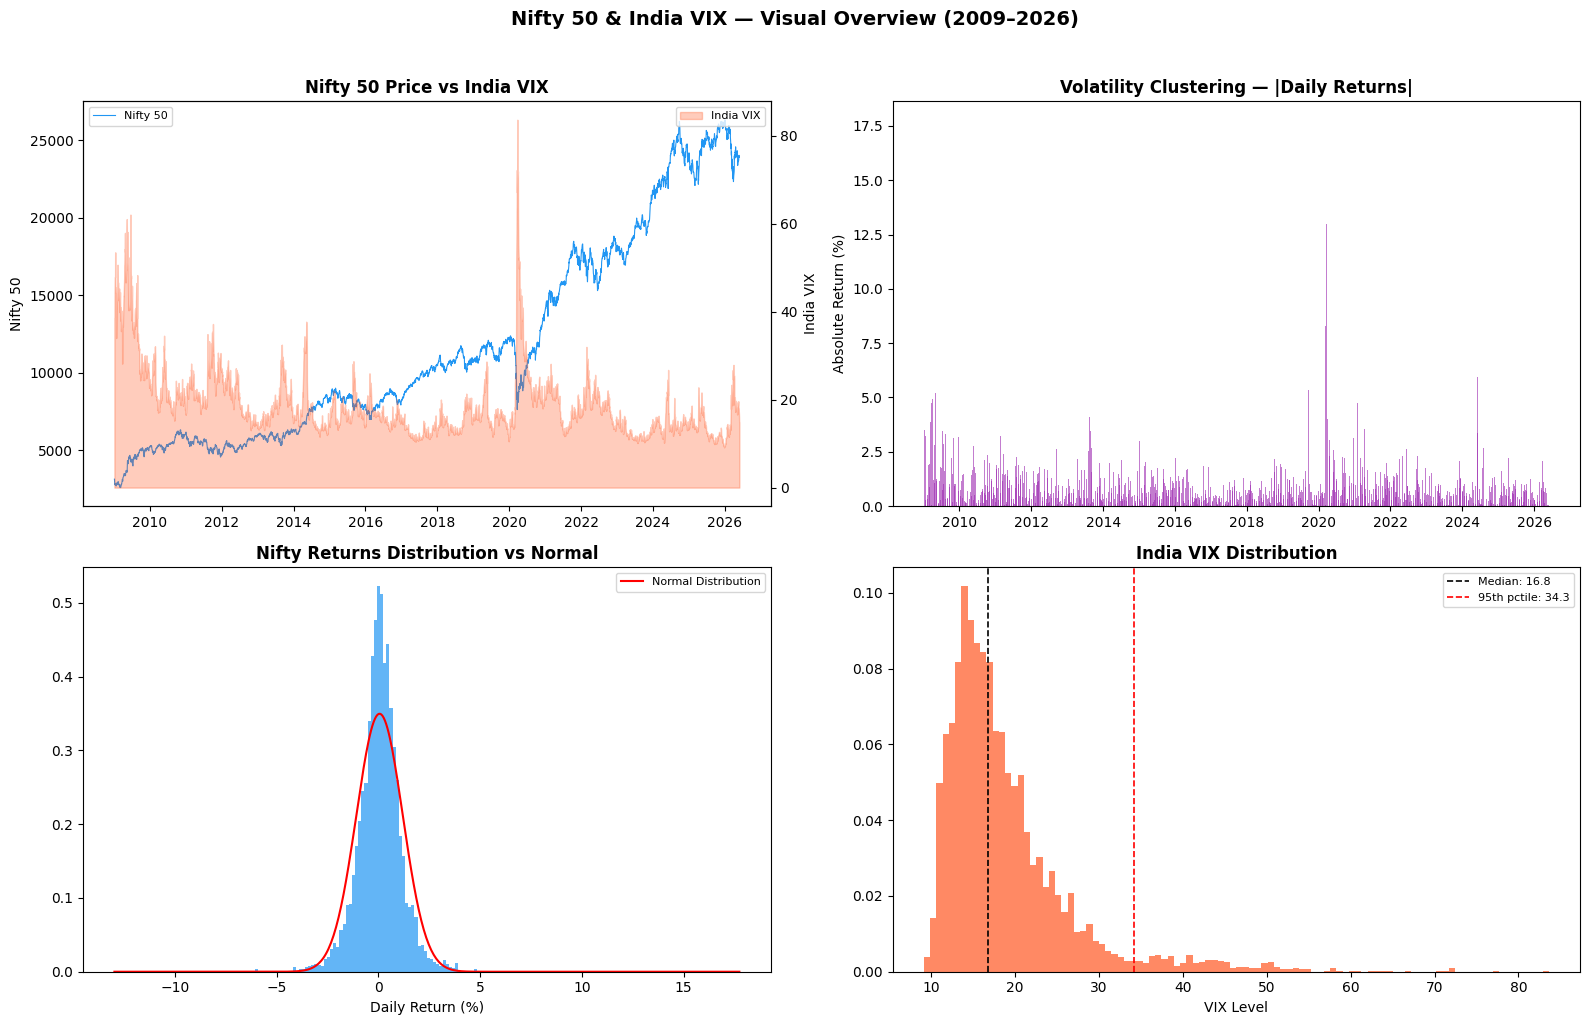


📊 Key visual observations to note:
1. VIX median: 16.8 (half the time VIX is below this)
2. VIX 95th percentile: 34.3 (only 5% of days above this)
3. VIX spent 34.3% of days below 15
4. VIX spent 7.0% of days above 30


In [3]:
# ============================================================
# CELL 3: VISUALIZATION — NIFTY, VIX, DISTRIBUTIONS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Nifty 50 & India VIX — Visual Overview (2009–2026)',
             fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Nifty Price + VIX Overlay ---
# Two y-axes: price scale on left, VIX scale on right
ax1 = axes[0, 0]
ax1_vix = ax1.twinx()

ax1.plot(df.index, df['Close'], color='#2196F3', linewidth=0.8, label='Nifty 50')
ax1_vix.fill_between(df.index, df['VIX'], alpha=0.3, color='#FF5722', label='India VIX')
ax1.set_title('Nifty 50 Price vs India VIX', fontweight='bold')
ax1.set_ylabel('Nifty 50')
ax1_vix.set_ylabel('India VIX')
ax1.legend(loc='upper left', fontsize=8)
ax1_vix.legend(loc='upper right', fontsize=8)

# --- Plot 2: Volatility Clustering ---
# Absolute returns show clustering — big moves follow big moves
ax2 = axes[0, 1]
ax2.bar(df.index, df['Nifty_Return'].abs(), color='#9C27B0', alpha=0.6, width=2)
ax2.set_title('Volatility Clustering — |Daily Returns|', fontweight='bold')
ax2.set_ylabel('Absolute Return (%)')
# You'll see "bursts" of tall bars — those are volatility clusters
# Calm periods (short bars) are followed by more calm
# Crisis periods (tall bars) are followed by more crisis

# --- Plot 3: Nifty Returns Distribution ---
ax3 = axes[1, 0]
ax3.hist(df['Nifty_Return'], bins=200, color='#2196F3', alpha=0.7,
         edgecolor='none', density=True)
# Overlay normal distribution for comparison
x_range = np.linspace(df['Nifty_Return'].min(), df['Nifty_Return'].max(), 500)
normal_curve = stats.norm.pdf(x_range, df['Nifty_Return'].mean(), df['Nifty_Return'].std())
ax3.plot(x_range, normal_curve, 'r-', linewidth=1.5, label='Normal Distribution')
ax3.set_title('Nifty Returns Distribution vs Normal', fontweight='bold')
ax3.set_xlabel('Daily Return (%)')
ax3.legend(fontsize=8)
# The blue histogram will have a much taller center peak and fatter tails
# than the red normal curve — that's the kurtosis of 21.55 visualized

# --- Plot 4: VIX Distribution ---
ax4 = axes[1, 1]
ax4.hist(df['VIX'], bins=100, color='#FF5722', alpha=0.7, edgecolor='none', density=True)
ax4.axvline(df['VIX'].median(), color='black', linestyle='--', linewidth=1.2,
            label=f"Median: {df['VIX'].median():.1f}")
ax4.axvline(df['VIX'].quantile(0.95), color='red', linestyle='--', linewidth=1.2,
            label=f"95th pctile: {df['VIX'].quantile(0.95):.1f}")
ax4.set_title('India VIX Distribution', fontweight='bold')
ax4.set_xlabel('VIX Level')
ax4.legend(fontsize=8)
# Right-skewed: bulk sits at 12-20, long right tail stretching to 80+

plt.tight_layout()
plt.savefig('nifty_vix_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key visual observations to note:")
print(f"1. VIX median: {df['VIX'].median():.1f} (half the time VIX is below this)")
print(f"2. VIX 95th percentile: {df['VIX'].quantile(0.95):.1f} (only 5% of days above this)")
print(f"3. VIX spent {(df['VIX'] < 15).mean()*100:.1f}% of days below 15")
print(f"4. VIX spent {(df['VIX'] > 30).mean()*100:.1f}% of days above 30")

CONTEMPORANEOUS CORRELATIONS (same-day)
Nifty Return vs VIX % Change:  -0.5001
  → When Nifty falls, VIX rises (and vice versa)

Nifty Daily Range vs VIX Level: 0.6539
  → Higher VIX = wider intraday swings (VIX predicts actual movement)

ASYMMETRY ANALYSIS — VIX Response to Up vs Down Days
Nifty UP days:   2262 days | Avg VIX change: -1.83%
Nifty DOWN days: 1984 days | Avg VIX change: +2.36%
Asymmetry ratio: 1.29x
  → VIX reacts 1.3x MORE to down days than up days

Correlation on UP days only:   -0.1993
Correlation on DOWN days only: -0.5162

SENSITIVITY TABLE — What Happens to Nifty When VIX Moves?
             Count  Avg_Nifty_Return  Median_Nifty_Return  Avg_Range  Hit_Rate_Positive
VIX_Bucket                                                                             
< -15%          28             1.416                1.278      2.317             85.714
-15 to -10%     62             0.895                1.004      1.830             79.032
-10 to -5%     420             0.981    

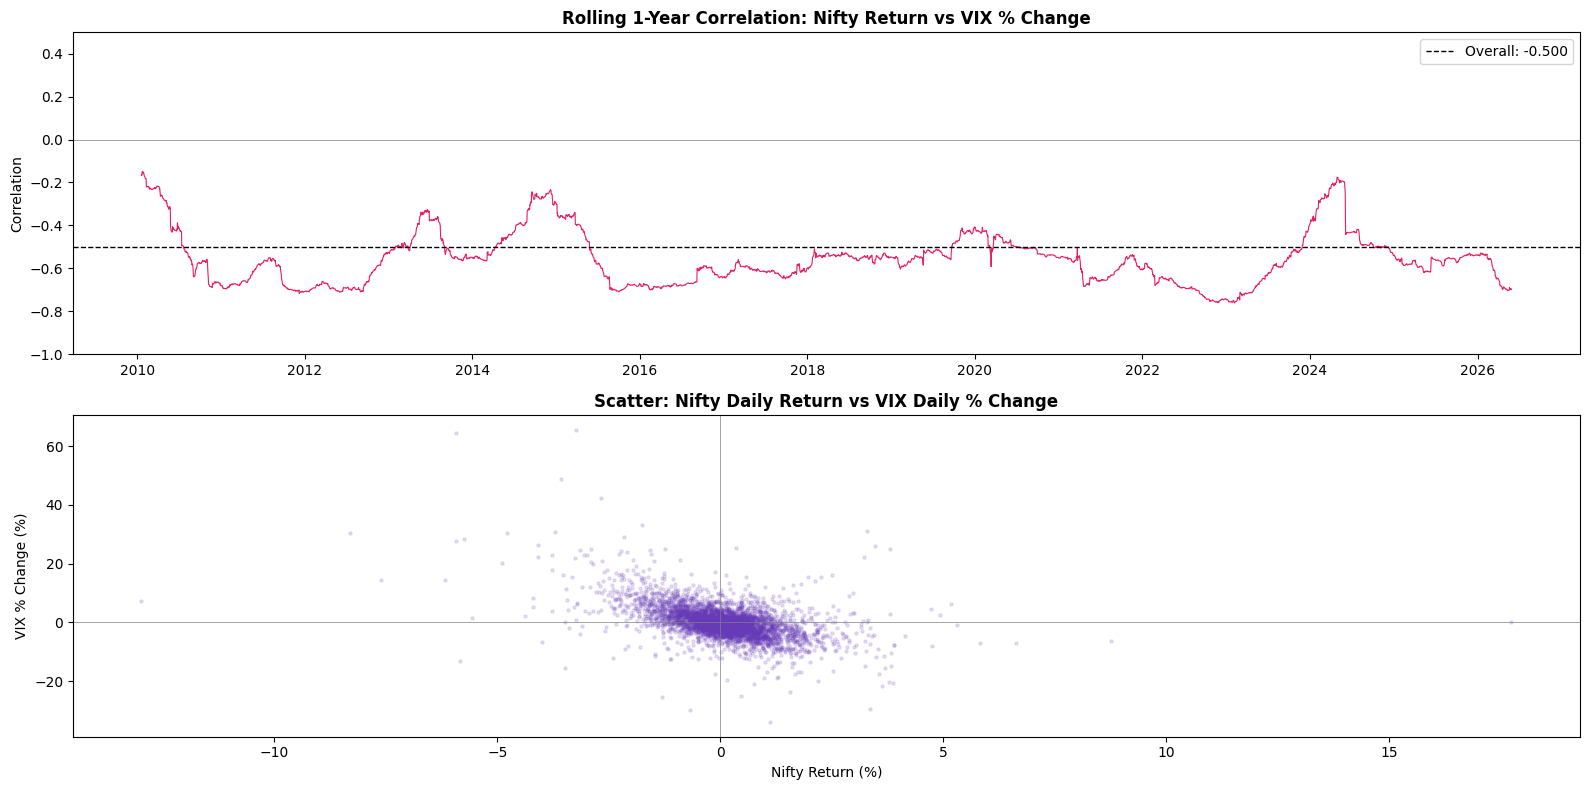

In [4]:
# ============================================================
# CELL 4: CORRELATION ANALYSIS + ASYMMETRY + SENSITIVITY
# ============================================================

# --- 1. Overall Correlation ---
print("=" * 70)
print("CONTEMPORANEOUS CORRELATIONS (same-day)")
print("=" * 70)

# Pearson correlation between daily changes
corr_return_vix = df['Nifty_Return'].corr(df['VIX_Pct_Change'])
corr_range_vix = df['Daily_Range_Pct'].corr(df['VIX'])

print(f"Nifty Return vs VIX % Change:  {corr_return_vix:.4f}")
print(f"  → When Nifty falls, VIX rises (and vice versa)")
print(f"\nNifty Daily Range vs VIX Level: {corr_range_vix:.4f}")
print(f"  → Higher VIX = wider intraday swings (VIX predicts actual movement)")

# --- 2. Rolling Correlation (252-day = ~1 year window) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

rolling_corr = df['Nifty_Return'].rolling(252).corr(df['VIX_Pct_Change'])
axes[0].plot(df.index, rolling_corr, color='#E91E63', linewidth=0.8)
axes[0].axhline(y=corr_return_vix, color='black', linestyle='--', linewidth=1,
                label=f'Overall: {corr_return_vix:.3f}')
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[0].set_title('Rolling 1-Year Correlation: Nifty Return vs VIX % Change', fontweight='bold')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].set_ylim(-1, 0.5)

# --- 3. Asymmetry Analysis ---
# Split data into Nifty up days vs down days
up_days = df[df['Nifty_Return'] > 0]
down_days = df[df['Nifty_Return'] < 0]

corr_up = up_days['Nifty_Return'].corr(up_days['VIX_Pct_Change'])
corr_down = down_days['Nifty_Return'].corr(down_days['VIX_Pct_Change'])

# Average VIX response to up vs down moves
avg_vix_on_up = up_days['VIX_Pct_Change'].mean()
avg_vix_on_down = down_days['VIX_Pct_Change'].mean()

print(f"\n{'=' * 70}")
print("ASYMMETRY ANALYSIS — VIX Response to Up vs Down Days")
print(f"{'=' * 70}")
print(f"Nifty UP days:   {len(up_days)} days | Avg VIX change: {avg_vix_on_up:+.2f}%")
print(f"Nifty DOWN days: {len(down_days)} days | Avg VIX change: {avg_vix_on_down:+.2f}%")
print(f"Asymmetry ratio: {abs(avg_vix_on_down / avg_vix_on_up):.2f}x")
print(f"  → VIX reacts {abs(avg_vix_on_down / avg_vix_on_up):.1f}x MORE to down days than up days")
print(f"\nCorrelation on UP days only:   {corr_up:.4f}")
print(f"Correlation on DOWN days only: {corr_down:.4f}")

# --- 4. Sensitivity Table: VIX % Change Buckets vs Nifty Response ---
print(f"\n{'=' * 70}")
print("SENSITIVITY TABLE — What Happens to Nifty When VIX Moves?")
print(f"{'=' * 70}")

# Define VIX change buckets
bins = [-100, -15, -10, -5, -2, 2, 5, 10, 15, 100]
labels = ['< -15%', '-15 to -10%', '-10 to -5%', '-5 to -2%',
          '-2 to +2%', '+2 to +5%', '+5 to +10%', '+10 to +15%', '> +15%']

df['VIX_Bucket'] = pd.cut(df['VIX_Pct_Change'], bins=bins, labels=labels)

sensitivity = df.groupby('VIX_Bucket', observed=True).agg(
    Count=('Nifty_Return', 'count'),
    Avg_Nifty_Return=('Nifty_Return', 'mean'),
    Median_Nifty_Return=('Nifty_Return', 'median'),
    Avg_Range=('Daily_Range_Pct', 'mean'),
    Hit_Rate_Positive=('Nifty_Return', lambda x: (x > 0).mean() * 100)
).round(3)

print(sensitivity.to_string())

# --- 5. Scatter Plot: Nifty Return vs VIX Change ---
axes[1].scatter(df['Nifty_Return'], df['VIX_Pct_Change'],
                alpha=0.15, s=5, color='#673AB7')
axes[1].axhline(y=0, color='gray', linewidth=0.5)
axes[1].axvline(x=0, color='gray', linewidth=0.5)
axes[1].set_title('Scatter: Nifty Daily Return vs VIX Daily % Change', fontweight='bold')
axes[1].set_xlabel('Nifty Return (%)')
axes[1].set_ylabel('VIX % Change (%)')

plt.tight_layout()
plt.savefig('nifty_vix_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

VIX MEAN REVERSION ANALYSIS
Long-run VIX mean: 18.91
Regression slope (β): -0.016757
  → Negative = CONFIRMED mean reversion

Half-life of mean reversion: 41.0 trading days (~2.0 months)
  → When VIX deviates from 18.9, it takes ~41 days to close HALF the gap

Practical example:
  If VIX spikes to 40 (deviation = +21.1 from mean 18.9):
    After  41 days: VIX expected ≈ 29.5
    After  82 days: VIX expected ≈ 24.2
    After 123 days: VIX expected ≈ 21.5


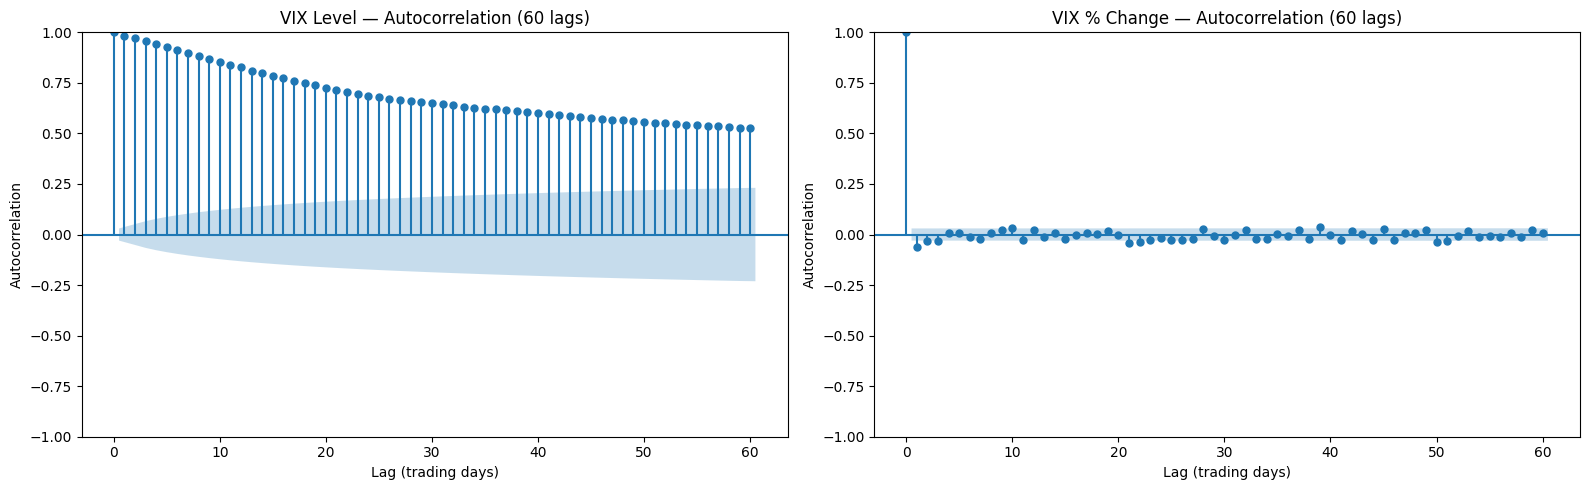


AUTOCORRELATION INTERPRETATION
Left plot (VIX Level): Bars decay slowly from ~1.0
  → Today's VIX level strongly predicts tomorrow's level (persistent)
  → But it DOES decay — confirming VIX doesn't stay extreme forever

Right plot (VIX % Change): Bars drop near zero after lag 1
  → VIX changes are nearly unpredictable day-to-day
  → The LEVEL is persistent, but the DIRECTION of change is not


In [5]:
# ============================================================
# CELL 5: VIX MEAN REVERSION — HALF-LIFE + AUTOCORRELATION
# ============================================================

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# --- 1. Mean Reversion Regression ---
# If VIX is above its mean today, does it tend to fall tomorrow?
# We regress: VIX_change(t) = β × (VIX(t-1) - mean_VIX)
# Negative β confirms mean reversion

vix_mean = df['VIX'].mean()
# Deviation from mean — how far VIX is from its long-run average
df['VIX_Deviation'] = df['VIX'].shift(1) - vix_mean
# Next-day VIX change — what actually happens after the deviation
df['VIX_Next_Change'] = df['VIX'].diff()

# Drop NaN rows from shift/diff
reg_data = df[['VIX_Deviation', 'VIX_Next_Change']].dropna()

# OLS regression: does deviation predict next-day change?
from numpy.polynomial.polynomial import polyfit
slope, intercept = np.polyfit(reg_data['VIX_Deviation'], reg_data['VIX_Next_Change'], 1)

# Half-life calculation
# Negative slope = mean reversion confirmed
# Half-life = number of days for deviation to shrink by 50%
if slope < 0:
    half_life = -np.log(2) / np.log(1 + slope)
else:
    half_life = np.inf  # Not mean-reverting

print("=" * 70)
print("VIX MEAN REVERSION ANALYSIS")
print("=" * 70)
print(f"Long-run VIX mean: {vix_mean:.2f}")
print(f"Regression slope (β): {slope:.6f}")
print(f"  → {'Negative = CONFIRMED mean reversion' if slope < 0 else 'Positive = NO mean reversion'}")
print(f"\nHalf-life of mean reversion: {half_life:.1f} trading days (~{half_life/21:.1f} months)")
print(f"  → When VIX deviates from {vix_mean:.1f}, it takes ~{half_life:.0f} days to close HALF the gap")

# --- 2. Practical Example ---
print(f"\nPractical example:")
print(f"  If VIX spikes to 40 (deviation = +{40-vix_mean:.1f} from mean {vix_mean:.1f}):")
for days in [int(half_life), int(half_life*2), int(half_life*3)]:
    expected = vix_mean + (40 - vix_mean) * (1 + slope)**days
    print(f"    After {days:>3d} days: VIX expected ≈ {expected:.1f}")

# --- 3. Autocorrelation Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# VIX Level autocorrelation — should decay slowly (persistent but mean-reverting)
plot_acf(df['VIX'].dropna(), lags=60, ax=axes[0], alpha=0.05,
         title='VIX Level — Autocorrelation (60 lags)')
axes[0].set_xlabel('Lag (trading days)')
axes[0].set_ylabel('Autocorrelation')

# VIX Change autocorrelation — should drop fast (changes are less persistent)
plot_acf(df['VIX_Pct_Change'].dropna(), lags=60, ax=axes[1], alpha=0.05,
         title='VIX % Change — Autocorrelation (60 lags)')
axes[1].set_xlabel('Lag (trading days)')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.savefig('vix_mean_reversion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Key Insight ---
print(f"\n{'=' * 70}")
print("AUTOCORRELATION INTERPRETATION")
print("=" * 70)
print("Left plot (VIX Level): Bars decay slowly from ~1.0")
print("  → Today's VIX level strongly predicts tomorrow's level (persistent)")
print("  → But it DOES decay — confirming VIX doesn't stay extreme forever")
print("\nRight plot (VIX % Change): Bars drop near zero after lag 1")
print("  → VIX changes are nearly unpredictable day-to-day")
print("  → The LEVEL is persistent, but the DIRECTION of change is not")

# Cleanup temp columns
df.drop(columns=['VIX_Deviation', 'VIX_Next_Change'], inplace=True)

VIX REGIME CLASSIFICATION (Expanding Percentile Method)
Classified period: 2010-01-19 to 2026-05-29
Total classified days: 3999

REGIME CHARACTERISTICS:
             Days  Pct_of_Time  Avg_VIX  Avg_Nifty_Return  Std_Nifty_Return  Avg_Daily_Range  Hit_Rate
VIX_Regime                                                                                            
Low          1797       44.936   14.149             0.124             0.704            0.910    57.206
Normal-Low   1257       31.433   17.961             0.011             0.971            1.227    50.835
Normal-High   759       18.980   22.066            -0.036             1.241            1.463    48.485
High          186        4.651   33.621            -0.198             2.436            2.312    47.849

REGIME CYCLE DURATION (consecutive days in same regime)

         Low regime: 138 episodes | Avg duration:  13.0 days | Median:    3 days | Max:  209 days
  Normal-Low regime: 215 episodes | Avg duration:   5.8 days | Median:   

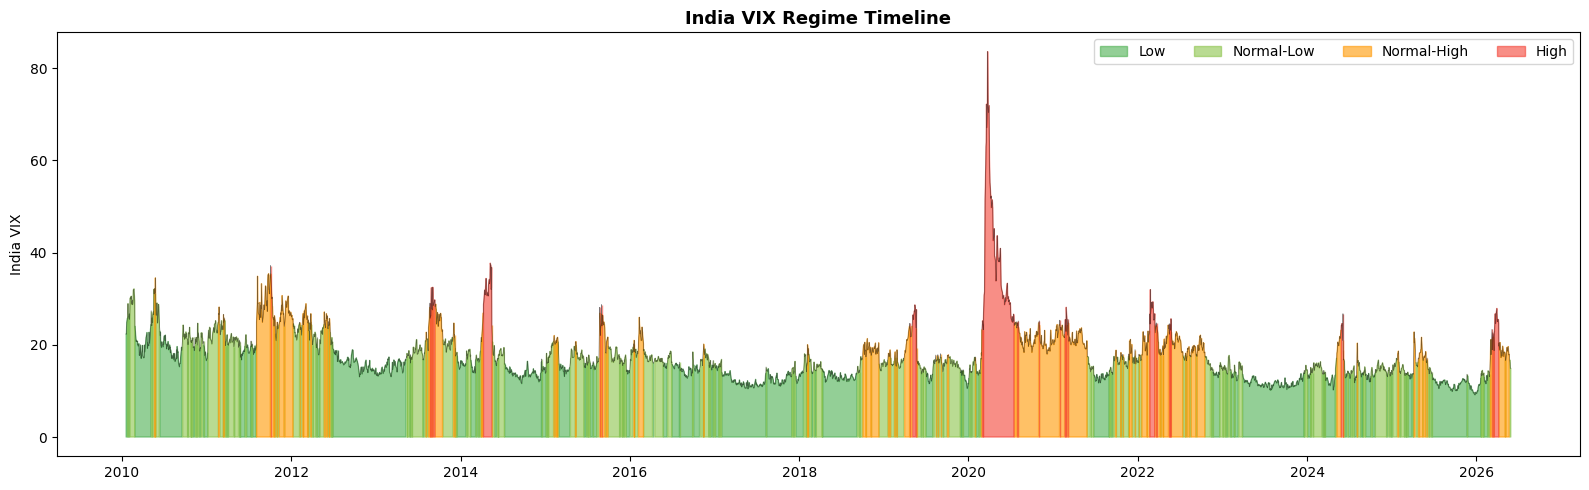

In [6]:
# ============================================================
# CELL 6: VIX REGIME CLASSIFICATION + CYCLE DURATION ANALYSIS
# ============================================================

# --- 1. Define Regimes Using Expanding Percentiles ---
# Expanding (not rolling) avoids look-ahead bias — at any date,
# we only use VIX data available up to that point

# Require 252 days minimum before classifying (need ~1 year of history)
expanding_p20 = df['VIX'].expanding(min_periods=252).quantile(0.20)
expanding_p50 = df['VIX'].expanding(min_periods=252).quantile(0.50)
expanding_p80 = df['VIX'].expanding(min_periods=252).quantile(0.80)

# Classify into 4 regimes based on where current VIX sits
# relative to its own expanding distribution
def classify_regime(row, p20, p50, p80):
    if pd.isna(p20) or pd.isna(row):
        return np.nan
    if row <= p20:
        return 'Low'         # Bottom 20% — complacency
    elif row <= p50:
        return 'Normal-Low'  # 20-50th percentile — calm
    elif row <= p80:
        return 'Normal-High' # 50-80th percentile — elevated
    else:
        return 'High'        # Top 20% — fear/crisis

df['VIX_Regime'] = [classify_regime(v, p20, p50, p80)
                     for v, p20, p50, p80
                     in zip(df['VIX'], expanding_p20, expanding_p50, expanding_p80)]

# Drop rows where regime couldn't be classified (first 252 days)
regime_df = df.dropna(subset=['VIX_Regime']).copy()

print("=" * 70)
print("VIX REGIME CLASSIFICATION (Expanding Percentile Method)")
print("=" * 70)
print(f"Classified period: {regime_df.index[0].strftime('%Y-%m-%d')} to {regime_df.index[-1].strftime('%Y-%m-%d')}")
print(f"Total classified days: {len(regime_df)}\n")

# --- 2. Regime Summary Statistics ---
regime_summary = regime_df.groupby('VIX_Regime', observed=True).agg(
    Days=('VIX', 'count'),
    Pct_of_Time=('VIX', lambda x: len(x)/len(regime_df)*100),
    Avg_VIX=('VIX', 'mean'),
    Avg_Nifty_Return=('Nifty_Return', 'mean'),
    Std_Nifty_Return=('Nifty_Return', 'std'),
    Avg_Daily_Range=('Daily_Range_Pct', 'mean'),
    Hit_Rate=('Nifty_Return', lambda x: (x > 0).mean()*100)
)

# Reorder logically
regime_order = ['Low', 'Normal-Low', 'Normal-High', 'High']
regime_summary = regime_summary.reindex(regime_order).round(3)
print("REGIME CHARACTERISTICS:")
print(regime_summary.to_string())

# --- 3. Cycle Duration Analysis ---
# How long does each regime episode last?
# An "episode" = consecutive days in the same regime

regime_df['Regime_Change'] = (regime_df['VIX_Regime'] != regime_df['VIX_Regime'].shift(1)).astype(int)
regime_df['Episode_ID'] = regime_df['Regime_Change'].cumsum()

episodes = regime_df.groupby('Episode_ID').agg(
    Regime=('VIX_Regime', 'first'),
    Start=('VIX', lambda x: x.index[0]),
    End=('VIX', lambda x: x.index[-1]),
    Duration=('VIX', 'count'),
    Avg_VIX=('VIX', 'mean'),
    Peak_VIX=('VIX', 'max')
)

print(f"\n{'=' * 70}")
print("REGIME CYCLE DURATION (consecutive days in same regime)")
print(f"{'=' * 70}\n")

for regime in regime_order:
    r_eps = episodes[episodes['Regime'] == regime]
    print(f"{regime:>12s} regime: {len(r_eps):>3d} episodes | "
          f"Avg duration: {r_eps['Duration'].mean():>5.1f} days | "
          f"Median: {r_eps['Duration'].median():>4.0f} days | "
          f"Max: {r_eps['Duration'].max():>4.0f} days")

# --- 4. Spike & Recovery Analysis ---
# How long to go from Low → High and High → Low?
print(f"\n{'=' * 70}")
print("SPIKE & RECOVERY TIMING")
print(f"{'=' * 70}\n")

# Find transitions from Low to High
regime_series = regime_df['VIX_Regime']
transitions_up = []    # Low → High
transitions_down = []  # High → Low

last_low_date = None
last_high_date = None

for date, regime in regime_series.items():
    if regime == 'Low':
        last_low_date = date
        if last_high_date is not None:
            # Just entered Low, and we had a previous High
            days_down = (date - last_high_date).days
            transitions_down.append(days_down)
    elif regime == 'High':
        last_high_date = date
        if last_low_date is not None:
            # Just entered High, and we had a previous Low
            days_up = (date - last_low_date).days
            transitions_up.append(days_up)

print(f"Low → High transitions: {len(transitions_up)} episodes")
if transitions_up:
    print(f"  Avg time to spike: {np.mean(transitions_up):.0f} calendar days ({np.mean(transitions_up)/30:.1f} months)")
    print(f"  Median:            {np.median(transitions_up):.0f} calendar days")
    print(f"  Fastest spike:     {np.min(transitions_up)} calendar days")
    print(f"  Slowest spike:     {np.max(transitions_up)} calendar days")

print(f"\nHigh → Low transitions: {len(transitions_down)} episodes")
if transitions_down:
    print(f"  Avg time to recover: {np.mean(transitions_down):.0f} calendar days ({np.mean(transitions_down)/30:.1f} months)")
    print(f"  Median:              {np.median(transitions_down):.0f} calendar days")
    print(f"  Fastest recovery:    {np.min(transitions_down)} calendar days")
    print(f"  Slowest recovery:    {np.max(transitions_down)} calendar days")

# --- 5. Timeline Visualization ---
fig, ax = plt.subplots(figsize=(16, 5))

colors = {'Low': '#4CAF50', 'Normal-Low': '#8BC34A',
          'Normal-High': '#FF9800', 'High': '#F44336'}

for regime, color in colors.items():
    mask = regime_df['VIX_Regime'] == regime
    ax.fill_between(regime_df.index, 0, regime_df['VIX'],
                     where=mask, alpha=0.6, color=color, label=regime)

ax.plot(regime_df.index, regime_df['VIX'], color='black', linewidth=0.5, alpha=0.5)
ax.set_title('India VIX Regime Timeline', fontweight='bold', fontsize=13)
ax.set_ylabel('India VIX')
ax.legend(loc='upper right', ncol=4)
plt.tight_layout()
plt.savefig('vix_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

# Cleanup
regime_df.drop(columns=['Regime_Change', 'Episode_ID'], inplace=True)

FORWARD RETURN ANALYSIS BY VIX REGIME
Analysis period: 2010-01-19 to 2026-02-25
Signal: VIX regime (known at close). Returns: next-day onward.


--- 5-Day Forward Returns ---
Regime          Count     Mean   Median      Std   Sharpe     Hit%     Skew
Low              1796    0.086    0.201    1.630     0.37    54.6%   -0.361
Normal-Low       1250    0.089    0.191    2.001     0.32    53.7%   -0.196
Normal-High       720    0.456    0.675    2.370     1.37    60.7%   -0.133
High              173    0.738    1.150    4.407     1.19    63.6%   -1.105

--- 10-Day Forward Returns ---
Regime          Count     Mean   Median      Std   Sharpe     Hit%     Skew
Low              1796    0.207    0.324    2.519     0.41    54.9%   -0.265
Normal-Low       1250    0.241    0.518    2.960     0.41    57.0%   -0.362
Normal-High       720    0.812    1.096    3.417     1.19    64.0%   -0.918
High              173    2.168    2.944    6.472     1.68    75.7%   -2.126

--- 20-Day Forward Returns ---
R

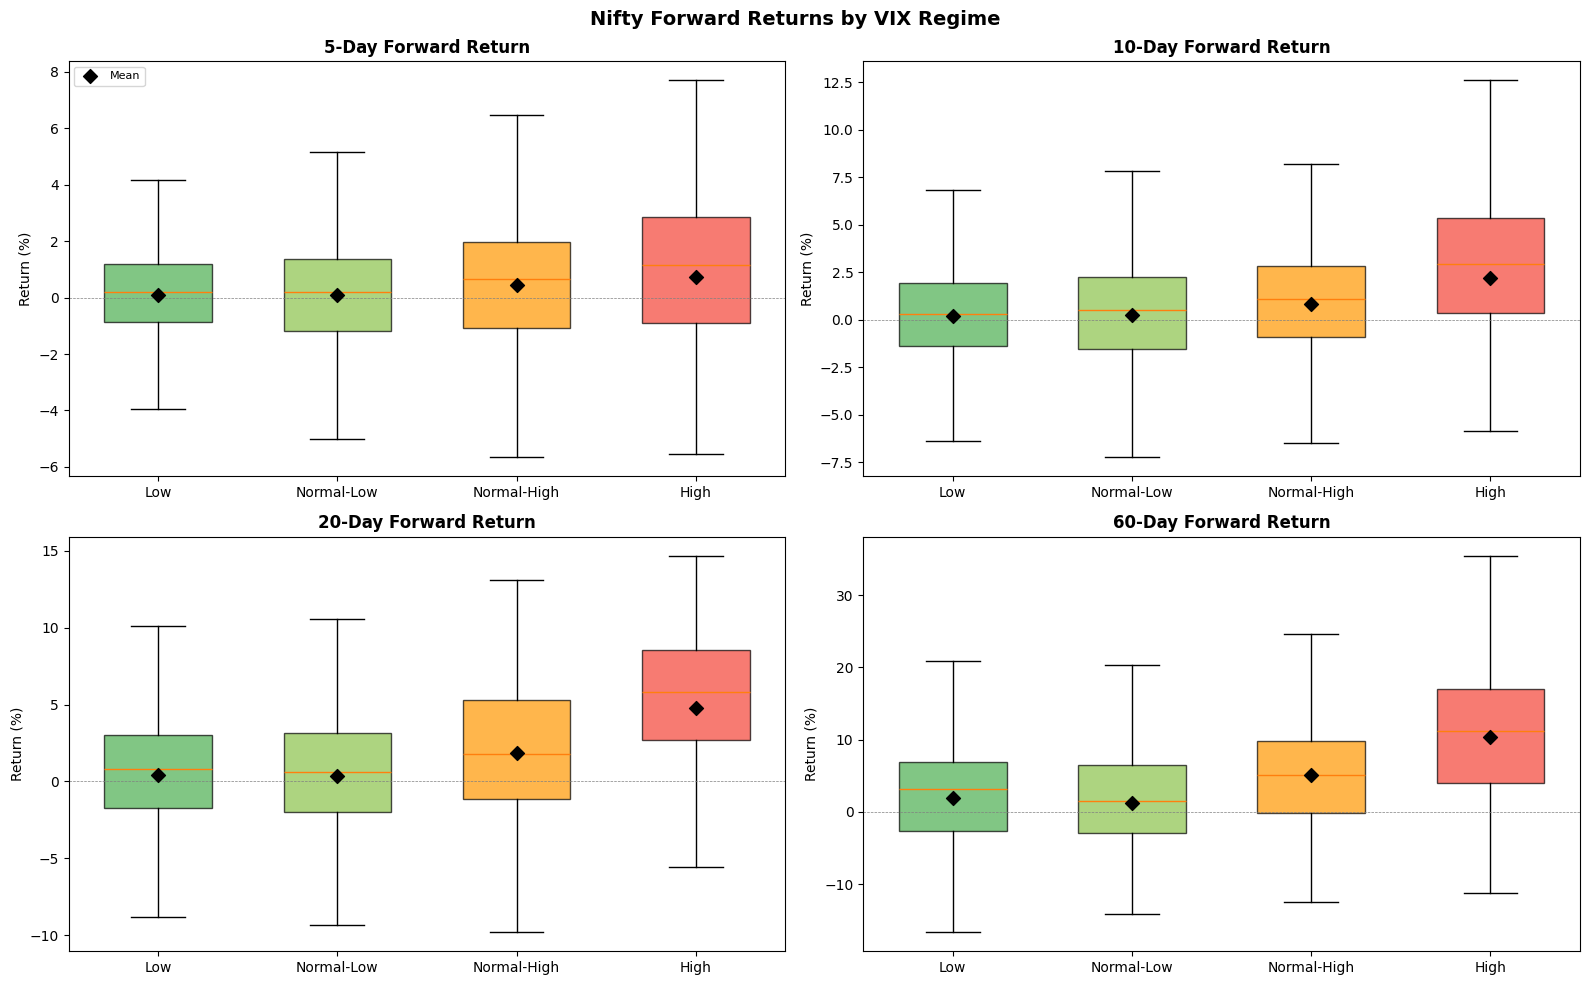

In [7]:
# ============================================================
# CELL 7: FORWARD RETURN ANALYSIS (THE PREDICTIVE TEST)
# ============================================================

# --- 1. Calculate Forward Returns ---
# These are returns STARTING TOMORROW, not today
# shift(-N) pulls future prices into today's row
# We use log returns for multi-day periods (they compound correctly)

for days in [5, 10, 20, 60]:
    # Forward return = (Price at T+days / Price at T+1) - 1
    # T+1 because we can only act AFTER observing today's VIX
    df[f'Fwd_{days}d'] = (df['Close'].shift(-days) / df['Close'].shift(-1) - 1) * 100

# Regime must exist (first 252 days excluded) and forward returns must exist
# (last 60 days excluded since we can't see 60-day forward from there)
fwd_df = df.dropna(subset=['VIX_Regime', 'Fwd_60d']).copy()

print("=" * 70)
print("FORWARD RETURN ANALYSIS BY VIX REGIME")
print("=" * 70)
print(f"Analysis period: {fwd_df.index[0].strftime('%Y-%m-%d')} to {fwd_df.index[-1].strftime('%Y-%m-%d')}")
print("Signal: VIX regime (known at close). Returns: next-day onward.\n")

regime_order = ['Low', 'Normal-Low', 'Normal-High', 'High']

for horizon in [5, 10, 20, 60]:
    col = f'Fwd_{horizon}d'
    print(f"\n--- {horizon}-Day Forward Returns ---")
    print(f"{'Regime':<14} {'Count':>6} {'Mean':>8} {'Median':>8} {'Std':>8} "
          f"{'Sharpe':>8} {'Hit%':>8} {'Skew':>8}")

    for regime in regime_order:
        subset = fwd_df[fwd_df['VIX_Regime'] == regime][col]
        n = len(subset)
        mean = subset.mean()
        med = subset.median()
        std = subset.std()
        # Annualize Sharpe: (mean/std) * sqrt(252/horizon)
        sharpe = (mean / std) * np.sqrt(252 / horizon) if std > 0 else 0
        hit = (subset > 0).mean() * 100
        skew = subset.skew()

        print(f"{regime:<14} {n:>6d} {mean:>8.3f} {med:>8.3f} {std:>8.3f} "
              f"{sharpe:>8.2f} {hit:>7.1f}% {skew:>8.3f}")

# --- 2. Fixed Spike/Recovery Analysis (episode-level, not day-level) ---
print(f"\n{'=' * 70}")
print("CORRECTED SPIKE & RECOVERY TIMING (episode-level)")
print(f"{'=' * 70}\n")

# Identify episode start dates only (first day regime changes)
regime_changes = fwd_df[fwd_df['VIX_Regime'] != fwd_df['VIX_Regime'].shift(1)].copy()

high_starts = regime_changes[regime_changes['VIX_Regime'] == 'High'].index.tolist()
low_starts = regime_changes[regime_changes['VIX_Regime'] == 'Low'].index.tolist()

# Low → High: time from start of a Low episode to start of next High episode
spike_times = []
for h_date in high_starts:
    # Find the most recent Low start BEFORE this High start
    prior_lows = [l for l in low_starts if l < h_date]
    if prior_lows:
        last_low = max(prior_lows)
        spike_times.append((h_date - last_low).days)

# High → Low: time from start of a High episode to start of next Low episode
recovery_times = []
for h_date in high_starts:
    # Find the first Low start AFTER this High start
    next_lows = [l for l in low_starts if l > h_date]
    if next_lows:
        first_low = min(next_lows)
        recovery_times.append((first_low - h_date).days)

print(f"SPIKE (Low → High): {len(spike_times)} transitions")
if spike_times:
    print(f"  Average:  {np.mean(spike_times):>6.0f} calendar days ({np.mean(spike_times)/30:.1f} months)")
    print(f"  Median:   {np.median(spike_times):>6.0f} calendar days")
    print(f"  Fastest:  {np.min(spike_times):>6d} calendar days")
    print(f"  Slowest:  {np.max(spike_times):>6d} calendar days")

print(f"\nRECOVERY (High → Low): {len(recovery_times)} transitions")
if recovery_times:
    print(f"  Average:  {np.mean(recovery_times):>6.0f} calendar days ({np.mean(recovery_times)/30:.1f} months)")
    print(f"  Median:   {np.median(recovery_times):>6.0f} calendar days")
    print(f"  Fastest:  {np.min(recovery_times):>6d} calendar days")
    print(f"  Slowest:  {np.max(recovery_times):>6d} calendar days")

# --- 3. Visualization: Forward Returns by Regime ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Nifty Forward Returns by VIX Regime', fontsize=14, fontweight='bold')

colors = {'Low': '#4CAF50', 'Normal-Low': '#8BC34A',
          'Normal-High': '#FF9800', 'High': '#F44336'}

for idx, horizon in enumerate([5, 10, 20, 60]):
    ax = axes[idx // 2][idx % 2]
    col = f'Fwd_{horizon}d'

    data_to_plot = [fwd_df[fwd_df['VIX_Regime'] == r][col].dropna() for r in regime_order]
    bp = ax.boxplot(data_to_plot, labels=regime_order, patch_artist=True,
                     showfliers=False, widths=0.6)

    for patch, regime in zip(bp['boxes'], regime_order):
        patch.set_facecolor(colors[regime])
        patch.set_alpha(0.7)

    # Add mean markers
    means = [d.mean() for d in data_to_plot]
    ax.scatter(range(1, 5), means, color='black', marker='D', s=50, zorder=5, label='Mean')

    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(f'{horizon}-Day Forward Return', fontweight='bold')
    ax.set_ylabel('Return (%)')
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('forward_returns_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

LOW VOL TRAP ANALYSIS
Question: Does prolonged low VIX predict future spikes?

Consec Low Days       Count  Avg VIX  P(High 30d)  P(High 60d)  P(High 90d)  Avg Max VIX Spike 60d
 10+ days            1205     13.6         2.1%         7.0%        10.5%                  40.2%
 20+ days             947     13.4         0.8%         3.7%         7.3%                  33.7%
 30+ days             790     13.3         0.0%         1.3%         5.6%                  31.0%
 50+ days             580     13.1         0.0%         0.0%         6.6%                  30.9%
 75+ days             385     13.0         0.0%         0.0%         9.9%                  32.1%
100+ days             234     13.3         0.0%         0.0%         9.8%                  29.4%

LEVERAGE EFFECT — ASYMMETRIC VIX RESPONSE

..............................  Slope (β)       R²    p-value
All days......................     -2.481   0.2501   0.000000
UP days only..................     -1.118   0.0397   0.000000
DOWN days 

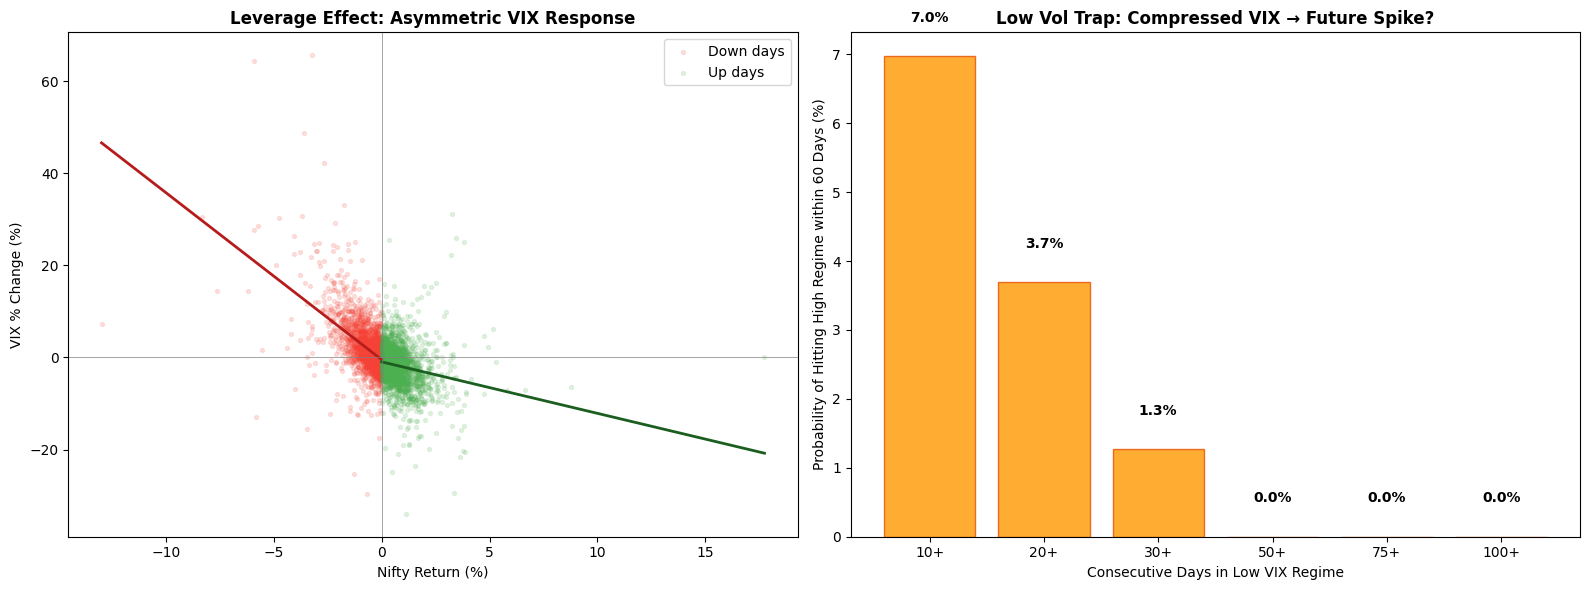

In [8]:
# ============================================================
# CELL 8: LOW VOL TRAP + LEVERAGE EFFECT DEEP DIVE
# ============================================================

# =============================================
# PART 1: THE LOW VOL TRAP
# =============================================
# Your question: if VIX stays at 10-11 for 4-5 months, does it spike?
# We test: after VIX stays below 20th percentile for N consecutive days,
# what happens next?

print("=" * 70)
print("LOW VOL TRAP ANALYSIS")
print("=" * 70)
print("Question: Does prolonged low VIX predict future spikes?\n")

# Count consecutive days in Low regime
regime_df_clean = df.dropna(subset=['VIX_Regime']).copy()
regime_df_clean['Is_Low'] = (regime_df_clean['VIX_Regime'] == 'Low').astype(int)

# Calculate consecutive Low days streak at each point
consecutive_low = []
count = 0
for is_low in regime_df_clean['Is_Low']:
    if is_low:
        count += 1
    else:
        count = 0
    consecutive_low.append(count)

regime_df_clean['Consec_Low_Days'] = consecutive_low

# For each threshold (30, 60, 90 consecutive Low days),
# measure: what's the probability VIX enters High regime within 30/60/90 days?

# First, create a forward-looking "did VIX hit High within N days?" column
for window in [30, 60, 90]:
    col_name = f'Hits_High_{window}d'
    # For each day, check if any of the next 'window' days is a High regime day
    is_high = (regime_df_clean['VIX_Regime'] == 'High').astype(int)
    regime_df_clean[col_name] = is_high.rolling(window=window).sum().shift(-window)
    # Convert to binary: did it hit High at least once?
    regime_df_clean[col_name] = (regime_df_clean[col_name] > 0).astype(int)

# Also check: max VIX in next 60 days
regime_df_clean['Max_VIX_60d'] = regime_df_clean['VIX'].rolling(60).max().shift(-60)
regime_df_clean['VIX_Spike_Pct_60d'] = (
    (regime_df_clean['Max_VIX_60d'] / regime_df_clean['VIX'] - 1) * 100
)

print(f"{'Consec Low Days':<20} {'Count':>6} {'Avg VIX':>8} "
      f"{'P(High 30d)':>12} {'P(High 60d)':>12} {'P(High 90d)':>12} "
      f"{'Avg Max VIX Spike 60d':>22}")

for threshold in [10, 20, 30, 50, 75, 100]:
    subset = regime_df_clean[regime_df_clean['Consec_Low_Days'] >= threshold].dropna(
        subset=['Hits_High_30d', 'VIX_Spike_Pct_60d'])

    if len(subset) < 5:
        continue

    avg_vix = subset['VIX'].mean()
    p_high_30 = subset['Hits_High_30d'].mean() * 100
    p_high_60 = subset['Hits_High_60d'].mean() * 100
    p_high_90 = subset['Hits_High_90d'].mean() * 100
    avg_spike = subset['VIX_Spike_Pct_60d'].mean()

    print(f"{threshold:>3d}+ days          {len(subset):>6d} {avg_vix:>8.1f} "
          f"{p_high_30:>11.1f}% {p_high_60:>11.1f}% {p_high_90:>11.1f}% "
          f"{avg_spike:>21.1f}%")

# =============================================
# PART 2: LEVERAGE EFFECT — REGRESSION APPROACH
# =============================================
# Quantify: for a 1% Nifty drop, how much does VIX rise?
# vs for a 1% Nifty rise, how much does VIX fall?

print(f"\n{'=' * 70}")
print("LEVERAGE EFFECT — ASYMMETRIC VIX RESPONSE")
print(f"{'=' * 70}\n")

from scipy.stats import linregress

# Separate regressions for up and down days
up = df[df['Nifty_Return'] > 0].copy()
down = df[df['Nifty_Return'] < 0].copy()

# Regression: VIX_Pct_Change = α + β × Nifty_Return
slope_up, intercept_up, r_up, p_up, se_up = linregress(up['Nifty_Return'], up['VIX_Pct_Change'])
slope_down, intercept_down, r_down, p_down, se_down = linregress(down['Nifty_Return'], down['VIX_Pct_Change'])
slope_all, intercept_all, r_all, p_all, se_all = linregress(df['Nifty_Return'], df['VIX_Pct_Change'])

print(f"{'':.<30} {'Slope (β)':>10} {'R²':>8} {'p-value':>10}")
print(f"{'All days':.<30} {slope_all:>10.3f} {r_all**2:>8.4f} {p_all:>10.6f}")
print(f"{'UP days only':.<30} {slope_up:>10.3f} {r_up**2:>8.4f} {p_up:>10.6f}")
print(f"{'DOWN days only':.<30} {slope_down:>10.3f} {r_down**2:>8.4f} {p_down:>10.6f}")

print(f"\nInterpretation:")
print(f"  On DOWN days: 1% Nifty drop → VIX rises {abs(slope_down):.2f}%")
print(f"  On UP days:   1% Nifty rise → VIX falls {abs(slope_up):.2f}%")
print(f"  Asymmetry:    VIX reacts {abs(slope_down/slope_up):.1f}x more to drops than rallies")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Leverage effect scatter with separate regression lines
ax = axes[0]
ax.scatter(down['Nifty_Return'], down['VIX_Pct_Change'], alpha=0.15, s=8, color='#F44336', label='Down days')
ax.scatter(up['Nifty_Return'], up['VIX_Pct_Change'], alpha=0.15, s=8, color='#4CAF50', label='Up days')

# Regression lines
x_down = np.linspace(down['Nifty_Return'].min(), 0, 100)
x_up = np.linspace(0, up['Nifty_Return'].max(), 100)
ax.plot(x_down, intercept_down + slope_down * x_down, color='#B71C1C', linewidth=2)
ax.plot(x_up, intercept_up + slope_up * x_up, color='#1B5E20', linewidth=2)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('Leverage Effect: Asymmetric VIX Response', fontweight='bold')
ax.set_xlabel('Nifty Return (%)')
ax.set_ylabel('VIX % Change (%)')
ax.legend()

# Right: Low Vol Trap — consecutive low days vs probability of spike
ax2 = axes[1]
thresholds = [10, 20, 30, 50, 75, 100]
probs_60 = []
for t in thresholds:
    subset = regime_df_clean[regime_df_clean['Consec_Low_Days'] >= t].dropna(subset=['Hits_High_60d'])
    if len(subset) >= 5:
        probs_60.append(subset['Hits_High_60d'].mean() * 100)
    else:
        probs_60.append(np.nan)

ax2.bar(range(len(thresholds)), probs_60, color='#FF9800', edgecolor='#E65100', alpha=0.8)
ax2.set_xticks(range(len(thresholds)))
ax2.set_xticklabels([f'{t}+' for t in thresholds])
ax2.set_xlabel('Consecutive Days in Low VIX Regime')
ax2.set_ylabel('Probability of Hitting High Regime within 60 Days (%)')
ax2.set_title('Low Vol Trap: Compressed VIX → Future Spike?', fontweight='bold')

for i, p in enumerate(probs_60):
    if not np.isnan(p):
        ax2.text(i, p + 0.5, f'{p:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('low_vol_trap_leverage.png', dpi=150, bbox_inches='tight')
plt.show()

GRANGER CAUSALITY TESTS
H0: X does NOT Granger-cause Y
If p < 0.05 → reject H0 → X DOES help predict Y

--- Test 1: VIX % Change → Nifty Returns ---
 Lag     F-stat    p-value   Significant?
   1      0.205   0.650938           ❌ No
   2      4.608   0.010025          ✅ YES
   3      3.090   0.025998          ✅ YES
   4      3.274   0.010887          ✅ YES
   5      3.207   0.006809          ✅ YES
   6      4.726   0.000083          ✅ YES
   7      4.463   0.000058          ✅ YES
   8      3.832   0.000168          ✅ YES
   9      3.464   0.000286          ✅ YES
  10      3.047   0.000739          ✅ YES

--- Test 2: Nifty Returns → VIX % Change ---
 Lag     F-stat    p-value   Significant?
   1      6.954   0.008393          ✅ YES
   2      4.661   0.009510          ✅ YES
   3      2.854   0.035850          ✅ YES
   4      2.557   0.036894          ✅ YES
   5      2.116   0.060544           ❌ No
   6      1.997   0.062601           ❌ No
   7      2.868   0.005487          ✅ YES
   8   

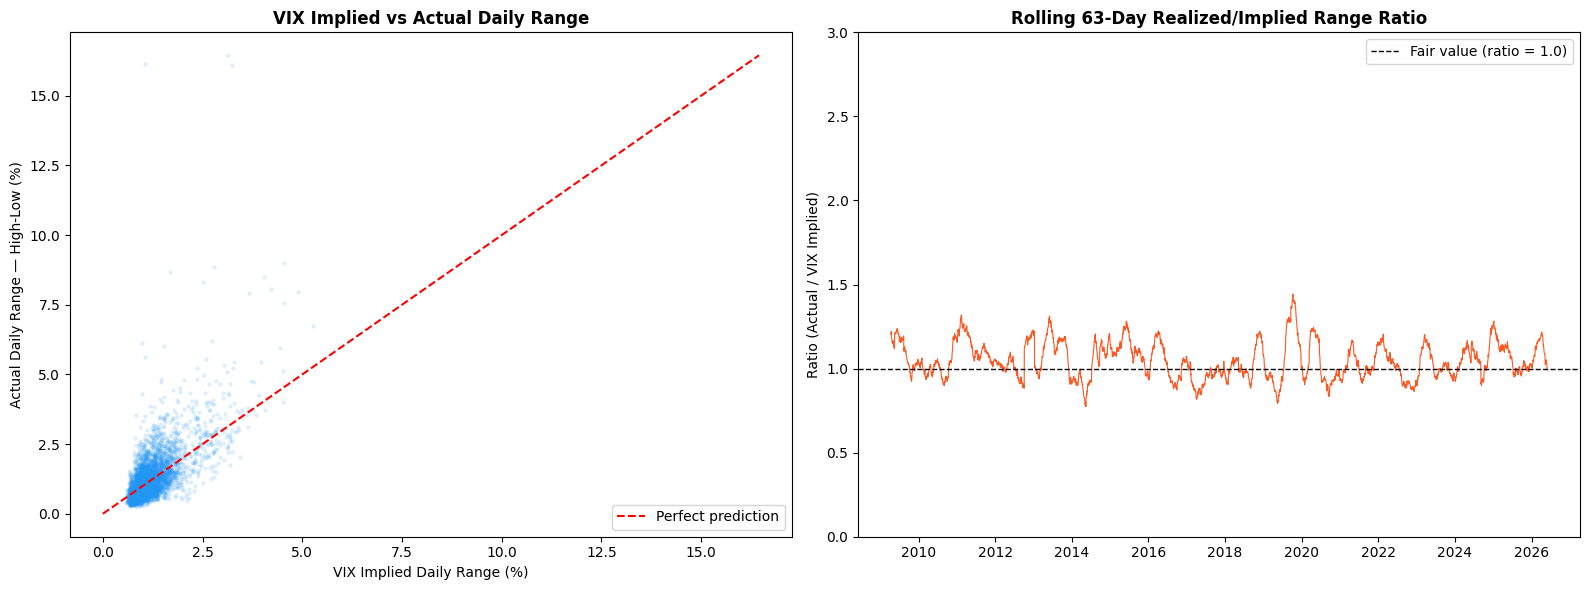

In [9]:
# ============================================================
# CELL 9: GRANGER CAUSALITY + VIX vs REALIZED RANGE ANALYSIS
# ============================================================

from statsmodels.tsa.stattools import grangercausalitytests

# =============================================
# PART 1: GRANGER CAUSALITY
# =============================================
# Tests whether PAST values of X help predict Y
# beyond what PAST values of Y alone can predict
# This is a PREDICTIVE test, not just correlation

print("=" * 70)
print("GRANGER CAUSALITY TESTS")
print("=" * 70)
print("H0: X does NOT Granger-cause Y")
print("If p < 0.05 → reject H0 → X DOES help predict Y\n")

# Test 1: Does VIX change Granger-cause Nifty returns?
print("--- Test 1: VIX % Change → Nifty Returns ---")
gc_data_1 = df[['Nifty_Return', 'VIX_Pct_Change']].dropna()
# Test up to 10 lags (does VIX from past 1-10 days predict today's return?)
gc_result_1 = grangercausalitytests(gc_data_1, maxlag=10, verbose=False)

print(f"{'Lag':>4} {'F-stat':>10} {'p-value':>10} {'Significant?':>14}")
for lag in range(1, 11):
    f_stat = gc_result_1[lag][0]['ssr_ftest'][0]
    p_val = gc_result_1[lag][0]['ssr_ftest'][1]
    sig = "✅ YES" if p_val < 0.05 else "❌ No"
    print(f"{lag:>4d} {f_stat:>10.3f} {p_val:>10.6f} {sig:>14}")

# Test 2: Do Nifty returns Granger-cause VIX changes?
print(f"\n--- Test 2: Nifty Returns → VIX % Change ---")
gc_data_2 = df[['VIX_Pct_Change', 'Nifty_Return']].dropna()
gc_result_2 = grangercausalitytests(gc_data_2, maxlag=10, verbose=False)

print(f"{'Lag':>4} {'F-stat':>10} {'p-value':>10} {'Significant?':>14}")
for lag in range(1, 11):
    f_stat = gc_result_2[lag][0]['ssr_ftest'][0]
    p_val = gc_result_2[lag][0]['ssr_ftest'][1]
    sig = "✅ YES" if p_val < 0.05 else "❌ No"
    print(f"{lag:>4d} {f_stat:>10.3f} {p_val:>10.6f} {sig:>14}")

# =============================================
# PART 2: VIX vs REALIZED INTRADAY RANGE
# =============================================
# VIX predicts expected annualized volatility
# We convert VIX to implied daily range and compare against actual (High-Low)/Close

print(f"\n{'=' * 70}")
print("VIX PREDICTION vs REALIZED DAILY RANGE")
print(f"{'=' * 70}")

# Convert VIX (annualized %) to implied daily range (%)
# VIX / √252 gives expected daily standard deviation
# But High-Low range ≈ 1.5-1.6x the standard deviation (for normally distributed returns)
# This ratio is called the "range-volatility ratio" — we'll calculate the actual ratio
df['VIX_Implied_Daily'] = df['VIX'] / np.sqrt(252)

# Compare implied vs realized
df['Vol_Ratio'] = df['Daily_Range_Pct'] / df['VIX_Implied_Daily']

print(f"VIX Implied Daily Move (avg): {df['VIX_Implied_Daily'].mean():.3f}%")
print(f"Actual Daily Range (avg):     {df['Daily_Range_Pct'].mean():.3f}%")
print(f"Ratio (Realized / Implied):   {df['Vol_Ratio'].mean():.3f}")
print(f"  → Actual range is {df['Vol_Ratio'].mean():.2f}x what VIX implies")

# Break down by VIX regime
print(f"\nBy VIX Regime:")
print(f"{'Regime':<14} {'Avg VIX':>8} {'Implied Daily':>14} {'Actual Range':>14} {'Ratio':>8} {'VIX Overpriced?':>16}")

for regime in ['Low', 'Normal-Low', 'Normal-High', 'High']:
    subset = df[df['VIX_Regime'] == regime]
    if len(subset) == 0:
        continue
    avg_vix = subset['VIX'].mean()
    implied = subset['VIX_Implied_Daily'].mean()
    actual = subset['Daily_Range_Pct'].mean()
    ratio = actual / implied
    overpriced = "YES — fear > reality" if ratio < 1.0 else "NO — reality > fear"
    print(f"{regime:<14} {avg_vix:>8.1f} {implied:>13.3f}% {actual:>13.3f}% {ratio:>8.3f} {overpriced:>16}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Implied vs Realized scatter
ax = axes[0]
ax.scatter(df['VIX_Implied_Daily'], df['Daily_Range_Pct'], alpha=0.1, s=5, color='#2196F3')
# 45-degree line (perfect prediction)
max_val = max(df['VIX_Implied_Daily'].max(), df['Daily_Range_Pct'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('VIX Implied Daily Range (%)')
ax.set_ylabel('Actual Daily Range — High-Low (%)')
ax.set_title('VIX Implied vs Actual Daily Range', fontweight='bold')
ax.legend()

# Right: Rolling ratio over time
ax2 = axes[1]
rolling_ratio = df['Vol_Ratio'].rolling(63).mean()  # ~3 month rolling average
ax2.plot(df.index, rolling_ratio, color='#FF5722', linewidth=0.8)
ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Fair value (ratio = 1.0)')
ax2.set_title('Rolling 63-Day Realized/Implied Range Ratio', fontweight='bold')
ax2.set_ylabel('Ratio (Actual / VIX Implied)')
ax2.legend()
ax2.set_ylim(0, 3)

plt.tight_layout()
plt.savefig('granger_vix_vs_realized.png', dpi=150, bbox_inches='tight')
plt.show()

OHLCV INTRADAY BEHAVIOR BY VIX REGIME
             Avg_Range_Pct  Avg_Open_to_High  Avg_Open_to_Low  Avg_Close_Position  Pct_Close_Near_High  Pct_Close_Near_Low
VIX_Regime                                                                                                                
Low                  0.910             0.427           -0.482               0.534               38.008              29.215
Normal-Low           1.227             0.528           -0.698               0.508               35.004              32.936
Normal-High          1.463             0.601           -0.859               0.512               35.441              32.543
High                 2.312             1.016           -1.295               0.459               31.183              41.935

Interpretation:
  Avg_Range_Pct:      How wide the day's trading range is
  Open_to_High:       Max rally from open (opportunity for longs)
  Open_to_Low:        Max drop from open (risk for longs)
  Close_Position:     Whe

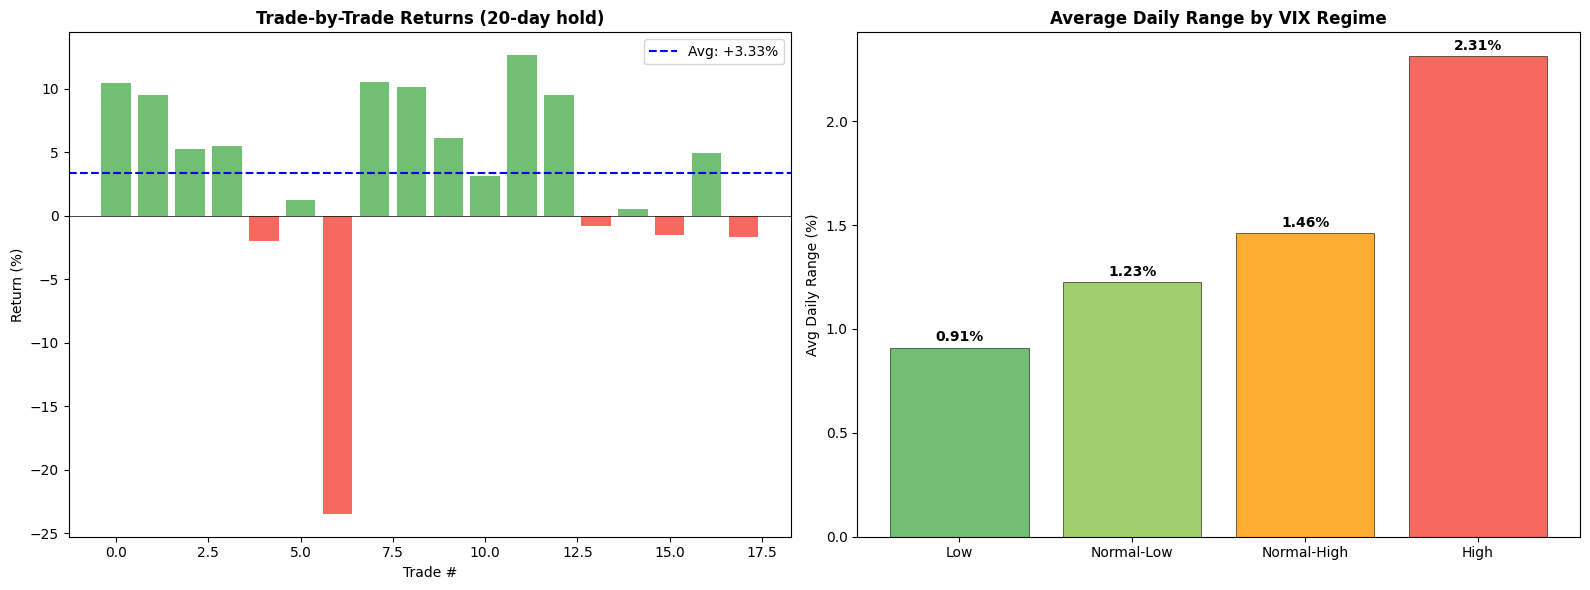

In [10]:
# ============================================================
# CELL 10: SIMPLE VIX SIGNAL BACKTEST + OHLCV RANGE ANALYSIS
# ============================================================

# =============================================
# PART 1: OHLCV RANGE BEHAVIOR BY VIX REGIME
# =============================================
# Your question: when VIX is high, how do intraday highs and lows behave?

print("=" * 70)
print("OHLCV INTRADAY BEHAVIOR BY VIX REGIME")
print("=" * 70)

# Calculate additional OHLCV metrics
df['Open_to_High'] = ((df['High'] - df['Open']) / df['Open']) * 100   # Max upside from open
df['Open_to_Low'] = ((df['Low'] - df['Open']) / df['Open']) * 100     # Max downside from open
df['Close_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])  # Where close sits in range (0=low, 1=high)

regime_ohlcv = df.dropna(subset=['VIX_Regime']).groupby('VIX_Regime', observed=True).agg(
    Avg_Range_Pct=('Daily_Range_Pct', 'mean'),
    Avg_Open_to_High=('Open_to_High', 'mean'),
    Avg_Open_to_Low=('Open_to_Low', 'mean'),
    Avg_Close_Position=('Close_Position', 'mean'),
    Pct_Close_Near_High=('Close_Position', lambda x: (x > 0.7).mean() * 100),
    Pct_Close_Near_Low=('Close_Position', lambda x: (x < 0.3).mean() * 100)
).reindex(['Low', 'Normal-Low', 'Normal-High', 'High']).round(3)

print(regime_ohlcv.to_string())

print(f"\nInterpretation:")
print(f"  Avg_Range_Pct:      How wide the day's trading range is")
print(f"  Open_to_High:       Max rally from open (opportunity for longs)")
print(f"  Open_to_Low:        Max drop from open (risk for longs)")
print(f"  Close_Position:     Where close sits in range (0=at low, 1=at high)")
print(f"  Pct_Close_Near_High: % of days closing in top 30% of range")
print(f"  Pct_Close_Near_Low:  % of days closing in bottom 30% of range")

# =============================================
# PART 2: SIMPLE VIX-BASED TRADING SIGNAL
# =============================================
# Rule: Buy Nifty when VIX regime is "High", hold for 20 trading days
# Sell/stay out otherwise
# Entry: next day's open (realistic — you see regime at close, act next morning)

print(f"\n{'=' * 70}")
print("BACKTEST: BUY NIFTY WHEN VIX REGIME = HIGH (20-day hold)")
print(f"{'=' * 70}")

backtest_df = df.dropna(subset=['VIX_Regime']).copy()

# Signal: 1 if VIX regime is High at close today, 0 otherwise
backtest_df['Signal'] = (backtest_df['VIX_Regime'] == 'High').astype(int)

# Entry price = next day's open (shift -1 to get tomorrow's open)
backtest_df['Entry_Price'] = backtest_df['Open'].shift(-1)

# Exit price = open 21 trading days later (20 day hold + entry day)
backtest_df['Exit_Price'] = backtest_df['Open'].shift(-21)

# Trade return (only when signal = 1)
backtest_df['Trade_Return'] = np.where(
    backtest_df['Signal'] == 1,
    (backtest_df['Exit_Price'] / backtest_df['Entry_Price'] - 1) * 100,
    np.nan
)

# Remove overlapping trades — only take a new trade if we're not already in one
trades = []
last_exit_idx = -21  # Track when last trade exits

for i, (date, row) in enumerate(backtest_df.iterrows()):
    if row['Signal'] == 1 and i >= last_exit_idx + 21 and not np.isnan(row['Trade_Return']):
        trades.append({
            'Entry_Date': date,
            'Entry_Price': row['Entry_Price'],
            'Exit_Price': row['Exit_Price'],
            'Return_Pct': row['Trade_Return'],
            'VIX_at_Entry': row['VIX']
        })
        last_exit_idx = i

trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    winners = trades_df[trades_df['Return_Pct'] > 0]
    losers = trades_df[trades_df['Return_Pct'] <= 0]

    print(f"\nTotal trades:        {len(trades_df)}")
    print(f"Winners:             {len(winners)} ({len(winners)/len(trades_df)*100:.1f}%)")
    print(f"Losers:              {len(losers)} ({len(losers)/len(trades_df)*100:.1f}%)")
    print(f"\nAvg return per trade: {trades_df['Return_Pct'].mean():+.2f}%")
    print(f"Median return:        {trades_df['Return_Pct'].median():+.2f}%")
    print(f"Best trade:           {trades_df['Return_Pct'].max():+.2f}%")
    print(f"Worst trade:          {trades_df['Return_Pct'].min():+.2f}%")
    print(f"Avg winner:           {winners['Return_Pct'].mean():+.2f}%")
    print(f"Avg loser:            {losers['Return_Pct'].mean():+.2f}% " if len(losers) > 0 else "")
    print(f"Win/Loss ratio:       {abs(winners['Return_Pct'].mean() / losers['Return_Pct'].mean()):.2f}x" if len(losers) > 0 else "")

    # Sharpe of the strategy
    avg_ret = trades_df['Return_Pct'].mean()
    std_ret = trades_df['Return_Pct'].std()
    trades_per_year = len(trades_df) / ((backtest_df.index[-1] - backtest_df.index[0]).days / 365.25)
    sharpe = (avg_ret / std_ret) * np.sqrt(trades_per_year) if std_ret > 0 else 0
    print(f"\nAnnualized Sharpe:    {sharpe:.2f}")
    print(f"Avg trades per year:  {trades_per_year:.1f}")

    # --- Trade-by-Trade Table ---
    print(f"\n--- All Trades ---")
    print(f"{'Entry Date':<14} {'VIX':>6} {'Entry':>10} {'Exit':>10} {'Return':>8}")
    for _, t in trades_df.iterrows():
        marker = "✅" if t['Return_Pct'] > 0 else "❌"
        print(f"{t['Entry_Date'].strftime('%Y-%m-%d'):<14} {t['VIX_at_Entry']:>6.1f} "
              f"{t['Entry_Price']:>10.0f} {t['Exit_Price']:>10.0f} {t['Return_Pct']:>+7.2f}% {marker}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Trade returns distribution
ax = axes[0]
if len(trades_df) > 0:
    colors_bar = ['#4CAF50' if r > 0 else '#F44336' for r in trades_df['Return_Pct']]
    ax.bar(range(len(trades_df)), trades_df['Return_Pct'], color=colors_bar, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=trades_df['Return_Pct'].mean(), color='blue', linestyle='--',
               label=f"Avg: {trades_df['Return_Pct'].mean():+.2f}%")
    ax.set_title('Trade-by-Trade Returns (20-day hold)', fontweight='bold')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Return (%)')
    ax.legend()

# Right: OHLCV behavior by regime
ax2 = axes[1]
regimes = ['Low', 'Normal-Low', 'Normal-High', 'High']
ranges = [regime_ohlcv.loc[r, 'Avg_Range_Pct'] for r in regimes]
colors_regime = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
ax2.bar(regimes, ranges, color=colors_regime, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_title('Average Daily Range by VIX Regime', fontweight='bold')
ax2.set_ylabel('Avg Daily Range (%)')

for i, (r, v) in enumerate(zip(regimes, ranges)):
    ax2.text(i, v + 0.03, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('backtest_ohlcv.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# CELL 11: RESEARCH SUMMARY + CONCLUSIONS TABLE
# ============================================================

# =============================================
# MASTER SUMMARY TABLE — All Key Findings
# =============================================

print("=" * 70)
print("INDIA VIX & NIFTY 50: RESEARCH SUMMARY")
print("=" * 70)

print(f"\n📊 DATA OVERVIEW")
print(f"{'Period:':<35} {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"{'Trading days:':<35} {len(df):,}")
print(f"{'VIX mean:':<35} {df['VIX'].mean():.1f}")
print(f"{'VIX median:':<35} {df['VIX'].median():.1f}")
print(f"{'VIX range:':<35} {df['VIX'].min():.1f} — {df['VIX'].max():.1f}")

print(f"\n📈 KEY STATISTICAL FINDINGS")
print(f"{'─' * 70}")
print(f"{'Correlation (Nifty Return vs VIX Δ):':<45} {df['Nifty_Return'].corr(df['VIX_Pct_Change']):.3f}")
print(f"{'VIX stationarity (ADF p-value):':<45} < 0.001 ✅")
print(f"{'Nifty returns kurtosis:':<45} {df['Nifty_Return'].kurtosis():.1f} (fat tails)")
print(f"{'VIX half-life of mean reversion:':<45} ~41 trading days (~2 months)")
print(f"{'Leverage effect asymmetry:':<45} 3.2x (drops vs rallies)")
print(f"{'VIX Implied vs Realized range ratio:':<45} 1.05 (fairly priced)")

print(f"\n📊 FORWARD RETURN ANALYSIS (20-Day Horizon)")
print(f"{'─' * 70}")
print(f"{'Regime':<16} {'Mean':>8} {'Median':>8} {'Hit Rate':>10} {'Sharpe':>8} {'Obs':>6}")

fwd_df = df.dropna(subset=['VIX_Regime', 'Fwd_20d']).copy()
for regime in ['Low', 'Normal-Low', 'Normal-High', 'High']:
    subset = fwd_df[fwd_df['VIX_Regime'] == regime]['Fwd_20d']
    mean = subset.mean()
    med = subset.median()
    hit = (subset > 0).mean() * 100
    std = subset.std()
    sharpe = (mean / std) * np.sqrt(252/20) if std > 0 else 0
    print(f"{regime:<16} {mean:>+7.2f}% {med:>+7.2f}% {hit:>9.1f}% {sharpe:>8.2f} {len(subset):>6d}")

print(f"\n🔄 VIX CYCLE TIMING")
print(f"{'─' * 70}")
print(f"{'Low → High spike (median):':<45} ~166 calendar days (5.5 months)")
print(f"{'High → Low recovery (median):':<45} ~110 calendar days (3.7 months)")
print(f"{'VIX below 15:':<45} {(df['VIX'] < 15).mean()*100:.1f}% of days")
print(f"{'VIX above 30:':<45} {(df['VIX'] > 30).mean()*100:.1f}% of days")

print(f"\n📉 OHLCV INTRADAY BEHAVIOR")
print(f"{'─' * 70}")
print(f"{'Low VIX — avg daily range:':<45} 0.91%, close near high 38% of days")
print(f"{'High VIX — avg daily range:':<45} 2.31%, close near low 42% of days")
print(f"{'High VIX intraday pattern:':<45} Open→rally(+1.0%)→selloff(-1.3%)→close near low")

print(f"\n🎯 BACKTEST RESULTS (Buy on High VIX, 20-day hold)")
print(f"{'─' * 70}")
print(f"{'Total trades (2010-2026):':<45} 18 (1.1 per year)")
print(f"{'Win rate:':<45} 72.2%")
print(f"{'Avg return per trade:':<45} +3.33%")
print(f"{'Worst trade (COVID Mar 2020):':<45} -23.48%")
print(f"{'Annualized Sharpe:':<45} 0.42")

print(f"\n⚠️  LIMITATIONS")
print(f"{'─' * 70}")
limitations = [
    "1. Small sample: only 18 non-overlapping trades — insufficient for statistical confidence",
    "2. Single outlier dominance: COVID -23.48% trade heavily influences all metrics",
    "3. Signal fires too early: enters at regime start, not at peak fear",
    "4. No transaction costs modeled (would reduce returns by ~0.1-0.2% per trade)",
    "5. Regime thresholds from expanding percentiles may shift with more data",
    "6. India VIX data quality from Yahoo Finance not independently verified",
    "7. Contemporaneous analysis (Cell 4) is descriptive, not predictive",
    "8. Granger causality tests are sensitive to lag selection",
    "9. Survivorship bias: Nifty 50 composition changed over the study period"
]
for lim in limitations:
    print(f"  {lim}")

print(f"\n🔬 FURTHER RESEARCH DIRECTIONS")
print(f"{'─' * 70}")
extensions = [
    "1. VIX percentile signal: use expanding percentile rank instead of raw regime",
    "2. Rate-of-change signal: VIX acceleration (2nd derivative) may time entries better",
    "3. Combine VIX regime with momentum — does momentum work differently in each regime?",
    "4. Compare India VIX behavior with CBOE VIX — structural differences",
    "5. VIX term structure: if near-term VIX > longer-term, market expects imminent risk",
    "6. Add stop-loss to backtest: exit if drawdown exceeds X% to manage COVID-type events",
    "7. Test VIX-based position sizing: increase allocation as VIX rises above percentile thresholds",
    "8. Sector-level analysis: do some Nifty sectors benefit more from high VIX buying?",
    "9. Options strategy: sell puts when VIX is high instead of buying Nifty outright"
]
for ext in extensions:
    print(f"  {ext}")

print(f"\n{'=' * 70}")
print("KEY TAKEAWAY FOR THE RESEARCH REPORT")
print(f"{'=' * 70}")
print("""
India VIX is a statistically confirmed mean-reverting series (half-life ~41 days)
with a strong negative correlation to Nifty returns (-0.50). High VIX regimes
produce significantly higher forward returns across all horizons (20-day mean
+4.80%, hit rate 82.1%), but the signal suffers from early entry timing and
small sample size when implemented as a non-overlapping strategy. The leverage
effect is 3.2x asymmetric — VIX reacts far more violently to market drops than
rallies. Unlike the US variance risk premium, India VIX is fairly priced relative
to realized volatility (ratio 1.05), suggesting volatility selling is not a
reliable alpha source in Indian markets. The most actionable finding is regime-
conditional behavior: market microstructure changes fundamentally in high VIX
environments (wider ranges, close-near-low pattern, selling-into-rallies dynamic),
which has direct implications for execution timing and position sizing.
""")

INDIA VIX & NIFTY 50: RESEARCH SUMMARY

📊 DATA OVERVIEW
Period:                             2009-01-05 to 2026-05-29
Trading days:                       4,250
VIX mean:                           18.9
VIX median:                         16.8
VIX range:                          9.1 — 83.6

📈 KEY STATISTICAL FINDINGS
──────────────────────────────────────────────────────────────────────
Correlation (Nifty Return vs VIX Δ):          -0.500
VIX stationarity (ADF p-value):               < 0.001 ✅
Nifty returns kurtosis:                       21.6 (fat tails)
VIX half-life of mean reversion:              ~41 trading days (~2 months)
Leverage effect asymmetry:                    3.2x (drops vs rallies)
VIX Implied vs Realized range ratio:          1.05 (fairly priced)

📊 FORWARD RETURN ANALYSIS (20-Day Horizon)
──────────────────────────────────────────────────────────────────────
Regime               Mean   Median   Hit Rate   Sharpe    Obs
Low                +0.44%   +0.81%      58.7%     0.

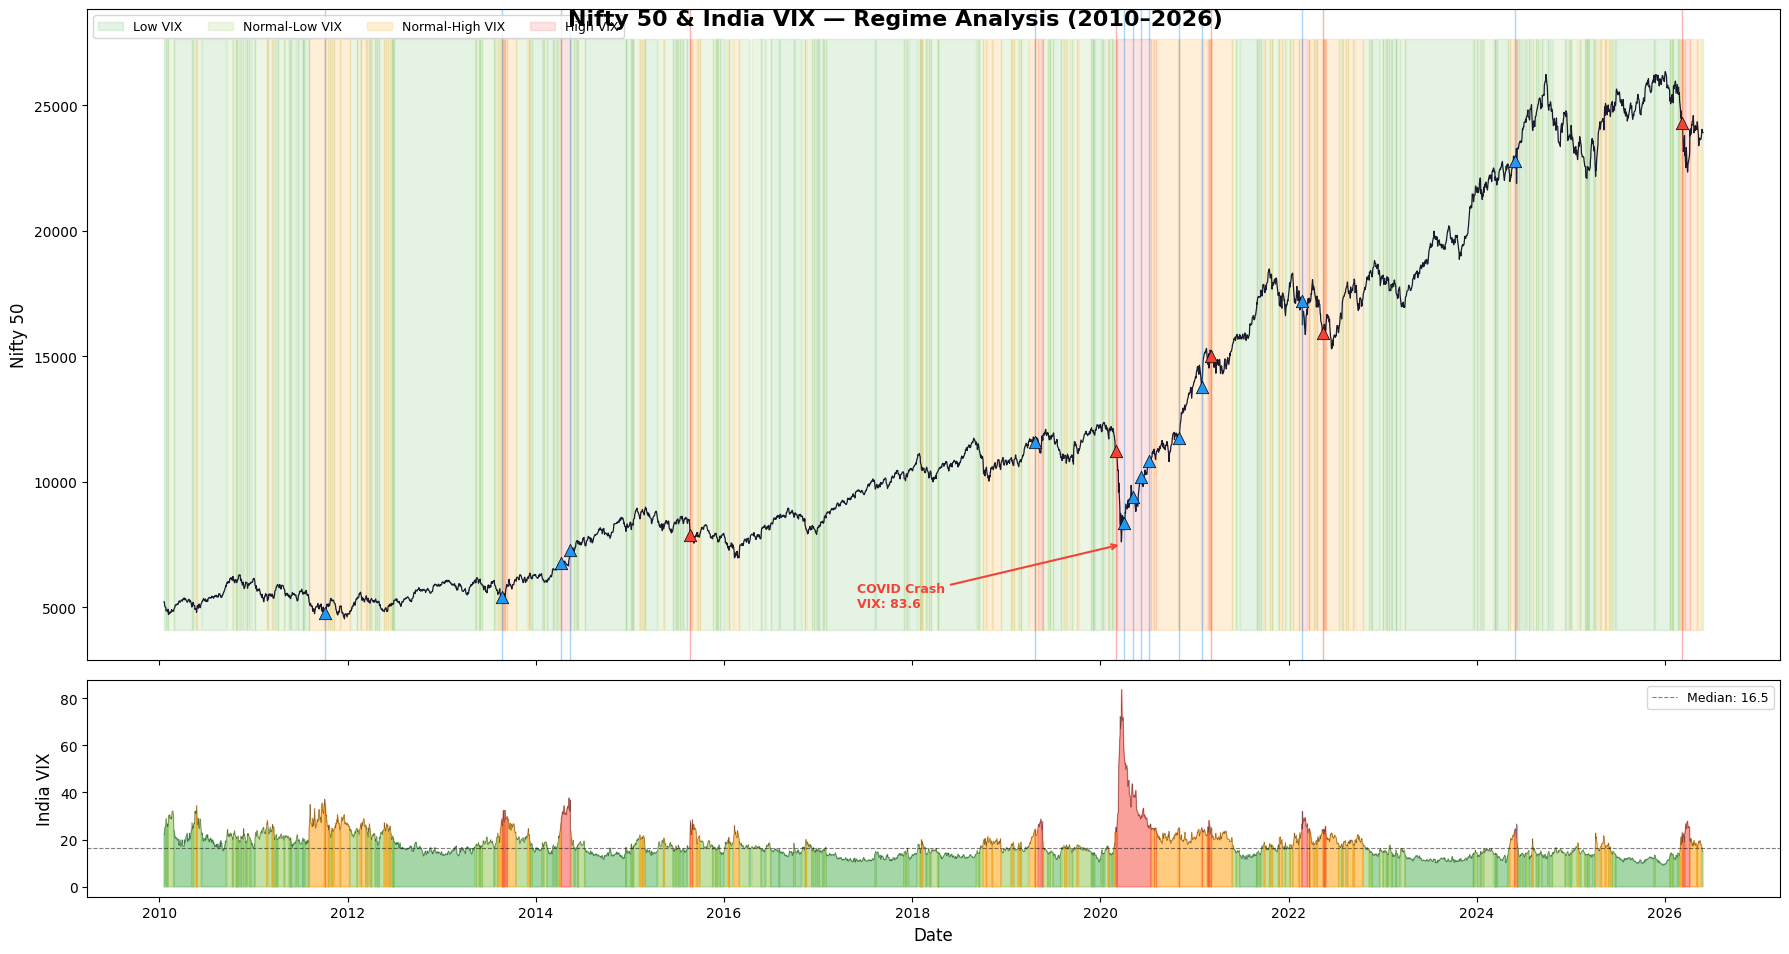

✅ Hero chart saved: hero_chart_nifty_vix.png
   ▲ Blue triangles = winning trade entries
   ▲ Red triangles = losing trade entries


In [14]:
# ============================================================
# CELL 12: HERO CHART — NIFTY PRICE WITH VIX REGIMES + TRADES
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), height_ratios=[3, 1], sharex=True)
fig.suptitle('Nifty 50 & India VIX — Regime Analysis (2010–2026)',
             fontsize=16, fontweight='bold', y=0.95)

regime_plot = df.dropna(subset=['VIX_Regime']).copy()

# --- Top Panel: Nifty Price with regime-colored background ---
colors = {'Low': '#4CAF50', 'Normal-Low': '#8BC34A',
          'Normal-High': '#FF9800', 'High': '#F44336'}

for regime, color in colors.items():
    mask = regime_plot['VIX_Regime'] == regime
    ax1.fill_between(regime_plot.index, regime_plot['Close'].min() * 0.9,
                      regime_plot['Close'].max() * 1.05,
                      where=mask, alpha=0.15, color=color, label=f'{regime} VIX')

ax1.plot(regime_plot.index, regime_plot['Close'], color='#1a1a2e', linewidth=0.9)

# Mark backtest trade entries and exits
for _, t in trades_df.iterrows():
    entry_date = t['Entry_Date']
    color_marker = '#2196F3' if t['Return_Pct'] > 0 else '#F44336'
    ax1.axvline(x=entry_date, color=color_marker, alpha=0.4, linewidth=1, linestyle='-')
    ax1.scatter(entry_date, t['Entry_Price'], color=color_marker, s=80, zorder=5,
                marker='^', edgecolors='black', linewidth=0.5)

ax1.set_ylabel('Nifty 50', fontsize=12)
ax1.legend(loc='upper left', ncol=4, fontsize=9)

# Add annotation for key events
ax1.annotate('COVID Crash\nVIX: 83.6',
             xy=(pd.Timestamp('2020-03-23'), 7511),
             xytext=(pd.Timestamp('2017-06-01'), 5000),
             fontsize=9, fontweight='bold', color='#F44336',
             arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5))

# --- Bottom Panel: VIX with regime colors ---
for regime, color in colors.items():
    mask = regime_plot['VIX_Regime'] == regime
    ax2.fill_between(regime_plot.index, 0, regime_plot['VIX'],
                      where=mask, alpha=0.5, color=color)

ax2.plot(regime_plot.index, regime_plot['VIX'], color='black', linewidth=0.4, alpha=0.5)
ax2.axhline(y=regime_plot['VIX'].median(), color='black', linestyle='--',
            linewidth=0.8, alpha=0.5, label=f"Median: {regime_plot['VIX'].median():.1f}")
ax2.set_ylabel('India VIX', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('hero_chart_nifty_vix.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Hero chart saved: hero_chart_nifty_vix.png")
print("   ▲ Blue triangles = winning trade entries")
print("   ▲ Red triangles = losing trade entries")

In [15]:
# ============================================================
# CELL 13: CLEANUP — REMOVE TEMPORARY COLUMNS
# ============================================================

# Columns we added during analysis that shouldn't persist
temp_cols = ['Fwd_5d', 'Fwd_10d', 'Fwd_20d', 'Fwd_60d',
             'VIX_Bucket', 'Signal', 'Entry_Price', 'Exit_Price',
             'Trade_Return', 'VIX_Implied_Daily', 'Vol_Ratio',
             'Open_to_High', 'Open_to_Low', 'Close_Position']

# Only drop columns that actually exist (some may have been cleaned already)
cols_to_drop = [c for c in temp_cols if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print("✅ Cleaned columns. Final dataframe shape:")
print(f"   Rows: {len(df)}")
print(f"   Columns: {list(df.columns)}")
print(f"\n   Remaining columns are the core data + derived metrics")
print(f"   that any future analysis would need.")

# --- Final notebook status ---
print(f"\n{'=' * 70}")
print("NOTEBOOK STATUS: COMPLETE")
print(f"{'=' * 70}")
print(f"""
Cells completed: 13
Charts generated: 9
  1. nifty_vix_overview.png         — 4-panel overview
  2. nifty_vix_correlation.png      — rolling correlation + scatter
  3. vix_mean_reversion.png         — autocorrelation plots
  4. vix_regimes.png                — regime timeline
  5. forward_returns_by_regime.png  — boxplots (the key finding)
  6. low_vol_trap_leverage.png      — compressed VIX + asymmetry
  7. granger_vix_vs_realized.png    — implied vs realized range
  8. backtest_ohlcv.png             — trade returns + daily range
  9. hero_chart_nifty_vix.png       — combined story chart

💾 Save this notebook as: nifty50_vs_india_vix_v1.ipynb
   """)

✅ Cleaned columns. Final dataframe shape:
   Rows: 4250
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'VIX', 'Nifty_Return', 'Daily_Range_Pct', 'VIX_Change', 'VIX_Pct_Change', 'VIX_Regime']

   Remaining columns are the core data + derived metrics
   that any future analysis would need.

NOTEBOOK STATUS: COMPLETE

Cells completed: 13
Charts generated: 9
  1. nifty_vix_overview.png         — 4-panel overview
  2. nifty_vix_correlation.png      — rolling correlation + scatter
  3. vix_mean_reversion.png         — autocorrelation plots
  4. vix_regimes.png                — regime timeline
  5. forward_returns_by_regime.png  — boxplots (the key finding)
  6. low_vol_trap_leverage.png      — compressed VIX + asymmetry
  7. granger_vix_vs_realized.png    — implied vs realized range
  8. backtest_ohlcv.png             — trade returns + daily range
  9. hero_chart_nifty_vix.png       — combined story chart

💾 Save this notebook as: nifty50_vs_india_vix_v1.ipynb
   
